In [1]:
# ═══════════════════════════════════════════════════════
# DREAM NARRATOR — Notebook 03: Decode and Narrate
# ═══════════════════════════════════════════════════════
# PURPOSE: Run the full decoding pipeline interactively.
# See exactly how brain states become dream concepts
# and how concepts become a narrative.

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import plotly.graph_objects as go

from configs.config_loader import config
from pipeline.data_loader import load_sleep_recording
from pipeline.preprocessor import bandpass_filter, remove_powerline_noise
from pipeline.feature_extractor import extract_features_from_epoch
from pipeline.neural_encoder import DreamEncoder
from pipeline.semantic_decoder import SemanticDecoder
from llm.story_chain import StoryChain
from viz.dream_timeline import CONCEPT_COLORS

print("Imports successful!")

FILE IS RUNNING
Imports successful!


In [7]:
# ── Load, preprocess and encode ──
data_dir       = config['data']['raw_dir']
psg_path       = os.path.join(data_dir, config['data']['psg_file'])
hypnogram_path = os.path.join(data_dir, config['data']['hypnogram_file'])

raw, annotations = load_sleep_recording(psg_path, hypnogram_path)
raw = remove_powerline_noise(raw)
raw = bandpass_filter(raw)

sfreq          = raw.info['sfreq']
data           = raw.get_data()
epoch_duration = int(sfreq * 30)
n_epochs       = min(10, data.shape[1] // epoch_duration)

# Extract and normalize features
features_list = []
for i in range(n_epochs):
    start      = i * epoch_duration
    end        = start + epoch_duration
    features, _ = extract_features_from_epoch(
        data[:, start:end], sfreq
    )
    features_list.append(features)

features_array = np.array(features_list)
mean           = features_array.mean(axis=0)
std            = features_array.std(axis=0) + 1e-10
features_norm  = [(f - mean) / std for f in features_list]

# Load encoder
model = DreamEncoder(
    input_dim=len(features_norm[0]),
    embedding_dim=config['encoder']['embedding_dim']
)
model.load_state_dict(
    torch.load(os.path.join('..', config['encoder']['model_path']))
)
model.eval()

# Generate embeddings
embeddings = []
with torch.no_grad():
    for features in features_norm:
        x            = torch.FloatTensor(features).unsqueeze(0)
        embedding, _ = model(x)
        embeddings.append(embedding.numpy().flatten())

print(f"Generated {len(embeddings)} dream fingerprints")
print(f"Fingerprint size: {len(embeddings[0])} dimensions")

Loading EEG recording from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf
Extracting EDF parameters from C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


Loading sleep stage annotations from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001EC-Hypnogram.edf
Removing powerline noise at 50.0 Hz
Filtering raw data in 1 contiguous segment


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:36: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 661 samples (6.610 s)

Applying bandpass filter: 0.5 - 45.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4

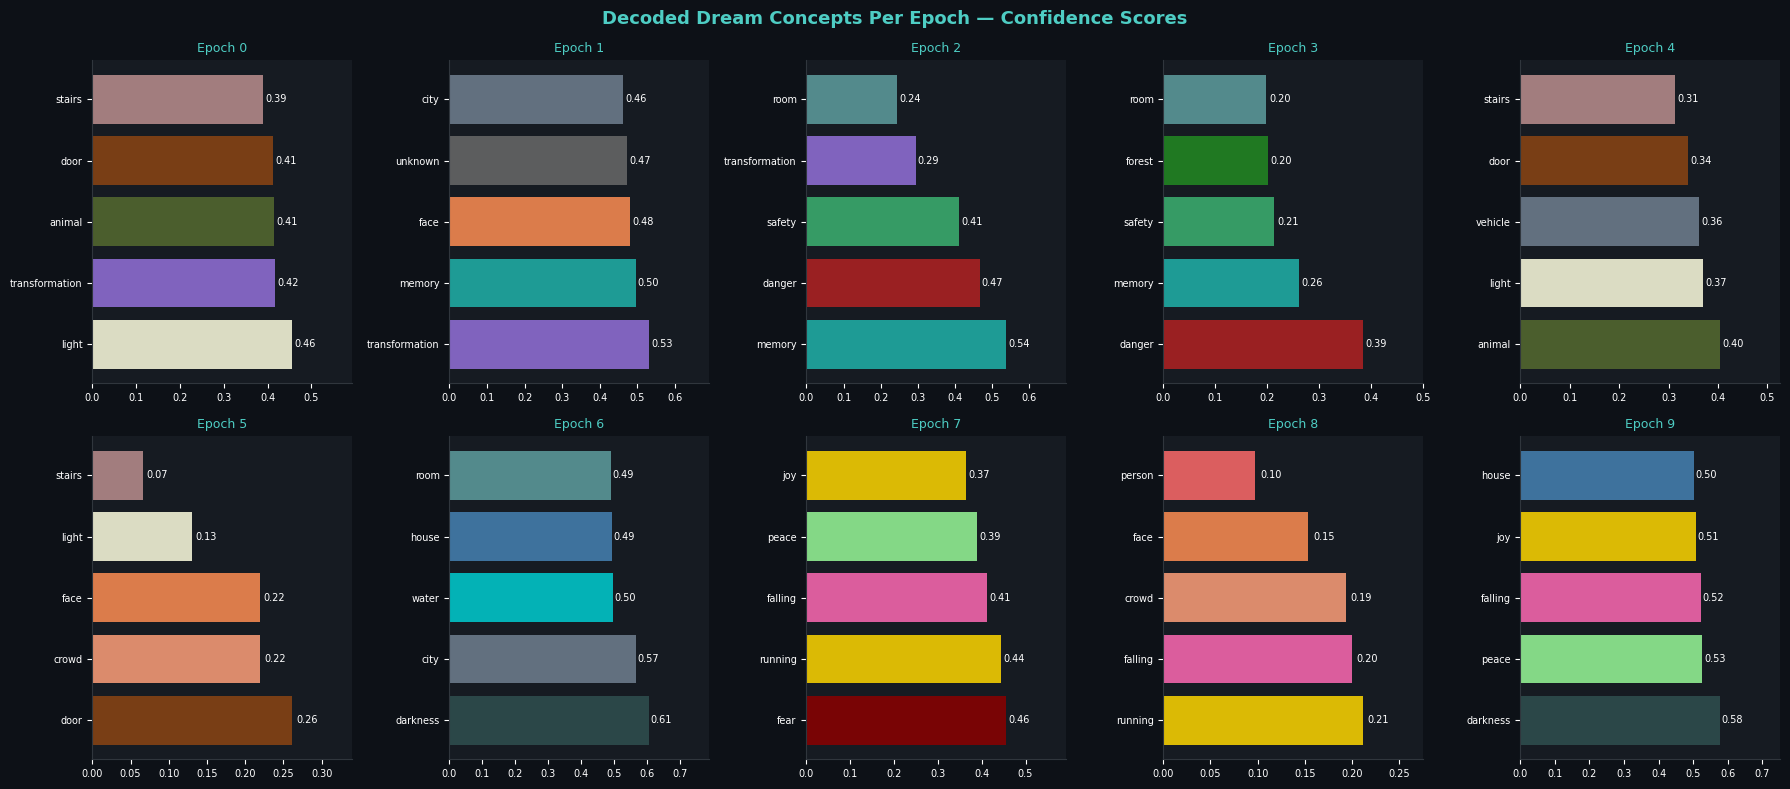


DOMINANT THEMES:
  memory          ███ (x3)
  transformation  ███ (x3)
  falling         ███ (x3)
  door            ███ (x3)
  light           ███ (x3)


In [8]:
# ── Decode concepts ──
# Let's decode AND visualize the confidence scores
# to understand how certain the decoder is about each concept

decoder          = SemanticDecoder(
    embedding_dim=config['encoder']['embedding_dim']
)
decoded_sequence = decoder.decode_sequence(
    [np.array(e) for e in embeddings],
    top_n=5  # get top 5 this time for richer visualization
)
dominant_themes  = decoder.summarize_sequence(decoded_sequence)

# ── Visualize concept confidence per epoch ──
fig, axes = plt.subplots(
    2, 5, figsize=(18, 8)
)
fig.patch.set_facecolor('#0D1117')

for idx, epoch_data in enumerate(decoded_sequence[:10]):
    row = idx // 5
    col = idx % 5
    ax  = axes[row][col]
    ax.set_facecolor('#161B22')

    concepts = epoch_data['concepts']
    names    = [c for c, s in concepts]
    scores   = [s for c, s in concepts]
    colors   = [CONCEPT_COLORS.get(c, '#4ECDC4') for c in names]

    bars = ax.barh(names, scores, color=colors, alpha=0.85)

    for bar, score in zip(bars, scores):
        ax.text(
            score + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center',
            color='white', fontsize=7
        )

    ax.set_title(f'Epoch {idx}',
                color='#4ECDC4', fontsize=9)
    ax.set_xlim(0, max(scores) * 1.3)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines['bottom'].set_color('#30363D')
    ax.spines['left'].set_color('#30363D')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Decoded Dream Concepts Per Epoch — Confidence Scores',
    color='#4ECDC4', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nDOMINANT THEMES:")
for concept, data_c in dominant_themes[:5]:
    bar = "█" * data_c['count']
    print(f"  {concept:15} {bar} (x{data_c['count']})")

In [9]:
# ── Compare different narrative styles ──
# Run the same decoded sequence through different styles
# and compare the outputs side by side

from llm.prompt_templates import NARRATIVE_STYLES, get_prompt
from groq import Groq
from dotenv import load_dotenv

load_dotenv(os.path.join('..', '.env'))

client = Groq(api_key=os.getenv('GROQ_API_KEY'))

styles_to_compare = ['vivid', 'psychological', 'poetic']
narratives        = {}

print("Generating narratives in 3 styles...\n")

for style in styles_to_compare:
    print(f"Generating {style} narrative...")
    system_prompt, user_prompt = get_prompt(
        style, decoded_sequence, dominant_themes
    )
    response = client.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': user_prompt}
        ],
        temperature=0.8,
        max_tokens=300
    )
    narratives[style] = response.choices[0].message.content
    print(f"Done!\n")

print("All narratives generated!")

Generating narratives in 3 styles...

Generating vivid narrative...
Done!

Generating psychological narrative...
Done!

Generating poetic narrative...
Done!

All narratives generated!


In [10]:
# ── Display all narratives ──
for style, narrative in narratives.items():
    print(f"{'='*60}")
    print(f"STYLE: {style.upper()}")
    print(f"{'='*60}")
    print(narrative)
    print()

STYLE: VIVID
You were standing in a bright, ethereal light at the top of a creaky, old-fashioned staircase, feeling an inexplicable urge to transform into something else. Your body began to shift and contort, your limbs stretching and morphing into those of a magnificent animal – a lion, perhaps, or a wolf – and you felt a surge of power and freedom. As you climbed the stairs, the door at the top swung open, beckoning you forward. You felt drawn to the unknown beyond, and with a final leap, you transformed into the creature, and the door creaked shut behind you, leaving you to explore the world below.

As you descended, the landscape shifted and changed, and you found yourself in a bustling city, surrounded by unfamiliar faces and sounds. A memory began to take shape, a moment from your past that you couldn't quite place, but it felt significant, like a puzzle piece falling into place. You saw a face, a stranger's face, but somehow it was also yours, and you felt a shiver run down your

In [11]:
# ── Run the full story chain ──
# This uses all 4 LLM steps for the richest output

print("Running full story chain (4 LLM calls)...\n")

chain  = StoryChain(style='vivid')
result = chain.run(decoded_sequence, dominant_themes)

print("=" * 60)
print("SUGGESTED TITLES:")
print(result['titles'])
print("\nDREAM SETTING:")
print(result['setting'])
print("\nEMOTIONAL ARC:")
print(result['emotional_arc'])

if result['characters']:
    print("\nDREAM CHARACTERS:")
    for char in result['characters']:
        print(f"  {char['name']}: {char['description']}")

print("\nFULL NARRATIVE:")
print("=" * 60)
print(result['narrative'])

Running full story chain (4 LLM calls)...

  Running story chain...
  Step 1/4: Extracting dream setting...
  Step 2/4: Mapping emotional arc...
  Step 3/4: Identifying dream characters...
  Step 4/4: Building full narrative...
SUGGESTED TITLES:
When Shadows Claim the Threshold

Beneath the Veil of Becoming

Falling into Forgotten Places

DREAM SETTING:
The primary setting of this dream appears to be a blend of various locations, but the dominant theme of transformation suggests a fluid, liminal space. This setting shifts between different times of day, often oscillating between twilight and dawn, with an atmosphere that is both eerie and transformative. Sensory details include the presence of light, darkness, water, and the sounds of crowds and running, creating a dynamic and disorienting environment that blurs the lines between reality and fantasy.

EMOTIONAL ARC:
Based on the decoded dream concepts, the emotional arc of this dream can be identified as follows:

1. Opening emotion: T

In [12]:
# ── Save the full report ──
report = f"""
DREAM NARRATOR — INTERACTIVE DECODE REPORT
{'='*60}

DECODED SEQUENCE:
{chr(10).join([
    f"  Epoch {e['epoch']}: {', '.join([c for c,s in e['concepts'][:3]])}"
    for e in decoded_sequence
])}

DOMINANT THEMES:
{chr(10).join([f"  {c}: {d['count']}x" for c,d in dominant_themes[:5]])}

SUGGESTED TITLES:
{result['titles']}

DREAM SETTING:
{result['setting']}

EMOTIONAL ARC:
{result['emotional_arc']}

FULL NARRATIVE:
{result['narrative']}
"""

report_path = os.path.join(
    '..', 'data', 'processed', 'interactive_dream_report.txt'
)
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"Report saved to {report_path}")
print("\nNotebook 03 complete!")

Report saved to ..\data\processed\interactive_dream_report.txt

Notebook 03 complete!
